In [1]:
# If needed
# !pip install pandas numpy scikit-learn nltk matplotlib seaborn

import pandas as pd
import numpy as np

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv('Civcraft.csv')

# Preview
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.364061e+09,328,self.Civcraft,1ava5d,"Banned, please operator read this. TEST POST, ...",bobpndrgn,404,76,69,http://www.reddit.com/r/Civcraft/comments/1ava...,...,False,self,t5_2tm1t,1365801307.0,NaN,MODERATOR-or-ADMIN,True,t3_1ava5d,http://www.reddit.com/r/Civcraft/comments/1ava...,moderator
1,1.367011e+09,270,self.Civcraft,1d6gt0,Well a disaster has occurred and it seems I on...,ttk2,307,37,263,http://www.reddit.com/r/Civcraft/comments/1d6g...,...,False,self,t5_2tm1t,1367011645.0,NaN,MODERATOR-or-ADMIN,True,t3_1d6gt0,http://www.reddit.com/r/Civcraft/comments/1d6g...,moderator
2,1.370365e+09,233,imgur.com,1fnt5t,Morning Change log for 2013-06-04,redpossum,265,32,29,http://www.reddit.com/r/Civcraft/comments/1fnt...,...,False,http://f.thumbs.redditmedia.com/1d2oatB8uy_8ik...,t5_2tm1t,False,NaN,NaN,False,t3_1fnt5t,http://imgur.com/a/kTiRl,NaN
3,1.354660e+09,205,i.imgur.com,14aagb,New? Here's the basics of PrisonPearl.,aholderith,234,29,45,http://www.reddit.com/r/Civcraft/comments/14aa...,...,False,http://c.thumbs.redditmedia.com/INlBpjE9t9j6mI...,t5_2tm1t,False,NaN,NaN,False,t3_14aagb,http://i.imgur.com/XbhkK.jpg,NaN
4,1.363486e+09,187,i.imgur.com,1afy66,5 hours and 5 cups of tea later...,aholderith,207,20,82,http://www.reddit.com/r/Civcraft/comments/1afy...,...,False,http://b.thumbs.redditmedia.com/efBABrp37I7p-M...,t5_2tm1t,False,NaN,NaN,False,t3_1afy66,http://i.imgur.com/V8HEyHZ.jpg,NaN


In [5]:
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.364061e+09,328,self.Civcraft,1ava5d,"Banned, please operator read this. TEST POST, ...",bobpndrgn,404,76,69,http://www.reddit.com/r/Civcraft/comments/1ava...,...,False,self,t5_2tm1t,1365801307.0,NaN,MODERATOR-or-ADMIN,True,t3_1ava5d,http://www.reddit.com/r/Civcraft/comments/1ava...,moderator
1,1.367011e+09,270,self.Civcraft,1d6gt0,Well a disaster has occurred and it seems I on...,ttk2,307,37,263,http://www.reddit.com/r/Civcraft/comments/1d6g...,...,False,self,t5_2tm1t,1367011645.0,NaN,MODERATOR-or-ADMIN,True,t3_1d6gt0,http://www.reddit.com/r/Civcraft/comments/1d6g...,moderator
2,1.370365e+09,233,imgur.com,1fnt5t,Morning Change log for 2013-06-04,redpossum,265,32,29,http://www.reddit.com/r/Civcraft/comments/1fnt...,...,False,http://f.thumbs.redditmedia.com/1d2oatB8uy_8ik...,t5_2tm1t,False,NaN,NaN,False,t3_1fnt5t,http://imgur.com/a/kTiRl,NaN
3,1.354660e+09,205,i.imgur.com,14aagb,New? Here's the basics of PrisonPearl.,aholderith,234,29,45,http://www.reddit.com/r/Civcraft/comments/14aa...,...,False,http://c.thumbs.redditmedia.com/INlBpjE9t9j6mI...,t5_2tm1t,False,NaN,NaN,False,t3_14aagb,http://i.imgur.com/XbhkK.jpg,NaN
4,1.363486e+09,187,i.imgur.com,1afy66,5 hours and 5 cups of tea later...,aholderith,207,20,82,http://www.reddit.com/r/Civcraft/comments/1afy...,...,False,http://b.thumbs.redditmedia.com/efBABrp37I7p-M...,t5_2tm1t,False,NaN,NaN,False,t3_1afy66,http://i.imgur.com/V8HEyHZ.jpg,NaN


In [7]:
print(df.columns)

Index(['created_utc', 'score', 'domain', 'id', 'title', 'author', 'ups',
       'downs', 'num_comments', 'permalink', 'selftext', 'link_flair_text',
       'over_18', 'thumbnail', 'subreddit_id', 'edited',
       'link_flair_css_class', 'author_flair_css_class', 'is_self', 'name',
       'url', 'distinguished'],
      dtype='str')


In [11]:
print(df.head())

    created_utc  score         domain      id  \
0  1.364061e+09    328  self.Civcraft  1ava5d   
1  1.367011e+09    270  self.Civcraft  1d6gt0   
2  1.370365e+09    233      imgur.com  1fnt5t   
3  1.354660e+09    205    i.imgur.com  14aagb   
4  1.363486e+09    187    i.imgur.com  1afy66   

                                               title      author  ups  downs  \
0  Banned, please operator read this. TEST POST, ...   bobpndrgn  404     76   
1  Well a disaster has occurred and it seems I on...        ttk2  307     37   
2                  Morning Change log for 2013-06-04   redpossum  265     32   
3             New? Here's the basics of PrisonPearl.  aholderith  234     29   
4                 5 hours and 5 cups of tea later...  aholderith  207     20   

   num_comments                                          permalink  ...  \
0            69  http://www.reddit.com/r/Civcraft/comments/1ava...  ...   
1           263  http://www.reddit.com/r/Civcraft/comments/1d6g...  ...   

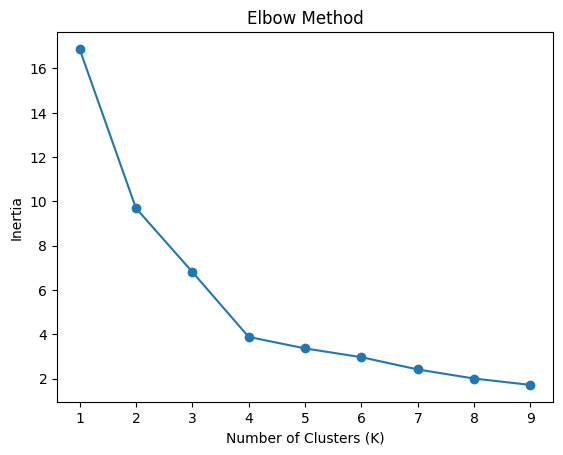

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Sample data
X = np.random.rand(100, 2)

inertia = []
K_range = range(1, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [15]:
print(len(df), len(X))

1000 100


In [20]:
print(hasattr(vectorizer, "vocabulary_"))  # should be True

False


In [24]:
print("X shape:", X.shape)
print("df shape:", df.shape)

X shape: (100, 2)
df shape: (1000, 22)
